# Session → Company Identification

**Goal:** Each session simulates one stock. Multiple companies appear in headlines per session, but only one company "owns" the session (its news actually drives the price). We want to identify which company each session belongs to.

**Approach:**
1. Extract the company name (first 2 words) from each headline.
2. For each headline at bar `t`, measure k-step price reactions (lookahead returns, volatility spikes).
3. Build per-company *reaction profiles* aggregated over all training sessions.
4. Score each candidate company in a session by how well its headline timings align with observed price moves.
5. Assign the best-scoring company as the session owner.

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 60)

DATA = '../data'

bars_seen   = pd.read_parquet(f'{DATA}/bars_seen_train.parquet')
bars_unseen = pd.read_parquet(f'{DATA}/bars_unseen_train.parquet')
bars_all    = pd.concat([bars_seen, bars_unseen]).sort_values(['session','bar_ix']).reset_index(drop=True)
headlines   = pd.read_parquet(f'{DATA}/headlines_seen_train.parquet')

print(f'Sessions: {bars_all["session"].nunique()}')
print(f'Bars per session (seen): {bars_seen.groupby("session")["bar_ix"].count().unique()}')
print(f'Bars per session (unseen): {bars_unseen.groupby("session")["bar_ix"].count().unique()}')
print(f'Headlines total: {len(headlines)}')
headlines.head(8)

Sessions: 1000
Bars per session (seen): [50]
Bars per session (unseen): [50]
Headlines total: 9740


,session,headline,bar_ix
0,0,Relvos Biosciences opens new office in Southeast Asia,6
1,0,Orevex Renewables secures $500M contract with a global retailer,12
2,0,Relvos Biosciences names new head of precision manufacturing division,14
3,0,Calvis Sciences secures $650M contract with a leading cloud platform,20
4,0,Yorvov Pharmaceuticals secures $180M contract with a national infrastructure...,22
5,0,Relvos Biosciences reports 3% decline in operating income,26
6,0,Relvos Biosciences secures $320M contract with a leading cloud platform,26
7,0,Calvis Sciences expands operations into Asia Pacific markets,33


## 1. Extract company names

In [142]:
headlines = headlines.copy()
headlines['company'] = headlines['headline'].str.split().str[:2].str.join(' ')

all_companies = sorted(headlines['company'].unique())
print(f'Unique companies: {len(all_companies)}')
print()
print('Top 20 by headline count:')
print(headlines['company'].value_counts().head(20))

Unique companies: 80

Top 20 by headline count:
company
Zelval Energy          169
Calvos Genomics        165
Myrnep Technologies    154
Halvax Networks        154
Crevol Retail          154
Talvyn Goods           151
Frelol Software        151
Relvon Fuels           150
Orevar Marketplace     146
Ulvon Renewables       146
Zelvon Biosciences     145
Grevon Biotech         139
Kelvik Power           139
Holtar Stores          138
Creven Securities      138
Ulvyn Microchips       136
Brevep Systems         136
Nerval Biopharma       132
Frelex Outlets         131
Wyrnik Sciences        130
Name: count, dtype: int64


In [143]:
# Companies per session
companies_per_session = headlines.groupby('session')['company'].nunique()
print('Companies mentioned per session:')
print(companies_per_session.value_counts().sort_index())

# Headlines per session
headlines_per_session = headlines.groupby('session')['headline'].count()
print()
print('Headlines per session stats:')
print(headlines_per_session.describe())

Companies mentioned per session:
company
1      2
2     42
3    250
4    706
Name: count, dtype: int64

Headlines per session stats:
count    1000.000000
mean        9.740000
std         2.999566
min         2.000000
25%         8.000000
50%        10.000000
75%        12.000000
max        21.000000
Name: headline, dtype: float64


## 2. Build bar-level price features

For each bar we compute:
- **ret_k**: close return k bars ahead (k=1,2,5)
- **vol_hl**: intrabar high-low spread (volatility proxy)
- **abs_ret_k**: absolute return (captures news-driven moves regardless of direction)

In [144]:
bars = bars_all.copy()

for k in [1, 2, 3, 15]:
    bars[f'ret_{k}'] = (
        bars.groupby('session')['close']
           .transform(lambda x: x.shift(-k) / x - 1)
    )

bars['vol_hl']  = bars['high'] - bars['low']
bars['vol_oc']  = (bars['close'] - bars['open']).abs()

bars.head(6)

,bar_ix,session,open,high,low,close,ret_1,ret_2,ret_3,ret_15,vol_hl,vol_oc
0,0,0,1.0000,1.0029,0.9986,0.9999,0.003400,0.002900,0.005701,0.017602,0.0043,0.0001
1,1,0,0.9997,1.0040,0.9991,1.0033,-0.000498,0.002292,0.001495,0.018638,0.0049,0.0036
2,2,0,1.0034,1.0040,1.0015,1.0028,0.002792,0.001994,-0.000199,0.023833,0.0025,0.0006
3,3,0,1.0023,1.0059,1.0021,1.0056,-0.000796,-0.002983,0.000796,0.020485,0.0038,0.0033
4,4,0,1.0057,1.0067,1.0043,1.0048,-0.002189,0.001592,0.002189,0.023786,0.0024,0.0009
5,5,0,1.0050,1.0051,1.0006,1.0026,0.003790,0.004389,0.008877,0.027030,0.0045,0.0024


## 3. Join headlines with bar features

Each headline arrives at a specific `bar_ix`. We join with bar features at that index to measure what the price did *after* the headline.

In [145]:
h = headlines.merge(bars, on=['session','bar_ix'], how='left')

print(h.shape)
h[['session','bar_ix','company','ret_1','ret_2','ret_15','vol_hl']].head(12)

(9740, 14)


,session,bar_ix,company,ret_1,ret_2,ret_15,vol_hl
0,0,6,Relvos Biosciences,0.000596,0.005068,0.025338,0.0037
1,0,12,Orevex Renewables,0.003448,0.002561,0.008964,0.0057
2,0,14,Relvos Biosciences,-0.000295,0.004127,0.006681,0.0046
3,0,20,Calvis Sciences,0.002137,-0.001748,-0.000971,0.0032
4,0,22,Yorvov Pharmaceuticals,0.001848,0.004767,0.001751,0.0073
5,0,26,Relvos Biosciences,-0.002435,-0.002045,0.002922,0.0042
6,0,26,Relvos Biosciences,-0.002435,-0.002045,0.002922,0.0042
7,0,33,Calvis Sciences,0.004201,0.005081,0.006253,0.0022
8,0,44,Yorvov Pharmaceuticals,-0.001553,-0.001844,0.003204,0.0038
9,0,47,Orevex Renewables,0.002336,0.003990,0.002822,0.0057


## 4. Per-company reaction profile

If company X owns a session, its headlines should consistently drive non-zero price reactions.
We compute the **mean absolute return** after each company's headline across all sessions.

In [146]:
# Company-level: average absolute k-step return following their headlines
company_profile = h.groupby('company').agg(
    n_headlines   = ('headline','count'),
    mean_abs_ret1 = ('ret_1', lambda x: x.abs().mean()),
    mean_abs_ret2 = ('ret_2', lambda x: x.abs().mean()),
    mean_abs_ret15 = ('ret_15', lambda x: x.abs().mean()),
    mean_ret1     = ('ret_1', 'mean'),
    mean_vol_hl   = ('vol_hl', 'mean'),
    n_sessions    = ('session', 'nunique'),
).sort_values('mean_abs_ret15', ascending=False)

print('Top companies by avg |ret_15| post-headline:')
company_profile.head(20)

Top companies by avg |ret_15| post-headline:


,n_headlines,mean_abs_ret1,mean_abs_ret2,mean_abs_ret15,mean_ret1,mean_vol_hl,n_sessions
company,,,,,,,
Holtum Asset,102,0.002235,0.003253,0.011680,-0.000135,0.003820,40
Relvan Software,118,0.002299,0.003294,0.011343,-0.000191,0.003834,41
Halvav Brands,98,0.002215,0.003137,0.011206,0.000302,0.004194,37
Jorval Trading,113,0.002054,0.003219,0.011185,-0.000001,0.003942,45
Arnik Commerce,103,0.002060,0.003179,0.011041,-0.000222,0.004214,35
Zelval Energy,169,0.002055,0.002976,0.011009,-0.000009,0.003780,58
Pleven Trading,101,0.001953,0.003184,0.010723,0.000083,0.003851,35
Jorvis Fuels,99,0.002358,0.003243,0.010688,0.000447,0.004034,40
Ilval Financial,109,0.002197,0.003008,0.010532,0.000170,0.003880,39


## 5. Session-level company scoring

**Core idea:** The company that "owns" a session will have its headlines time-aligned with the session's actual price movements. Noise companies will not.

For each session S and each company C mentioned in S:
- Get all bars where C posted a headline.
- Compute the **actual** k-step return at those bars.
- Score = mean absolute return at those bars (owner should have larger moves).

We also try:
- Headline count dominance (most-mentioned company)
- Volatility spike alignment
- Signed return consistency (owner's positive news → positive return)

In [147]:
# For each (session, company), compute reaction scores
session_company_scores = h.groupby(['session','company']).agg(
    n_headlines    = ('headline','count'),
    score_abs_ret1 = ('ret_1', lambda x: x.abs().mean()),
    score_abs_ret2 = ('ret_2', lambda x: x.abs().mean()),
    score_abs_ret15 = ('ret_15', lambda x: x.abs().mean()),
    score_vol_hl   = ('vol_hl', 'mean'),
    score_vol_oc   = ('vol_oc', 'mean'),
).reset_index()

# Combined score: weighted sum of normalized absolute returns
for col in ['score_abs_ret1','score_abs_ret2','score_abs_ret15','score_vol_hl','score_vol_oc']:
    mu, sigma = session_company_scores[col].mean(), session_company_scores[col].std()
    session_company_scores[col+'_z'] = (session_company_scores[col] - mu) / (sigma + 1e-9)

session_company_scores['combined_score'] = (
    session_company_scores['score_abs_ret1_z'] * 0.3 +
    session_company_scores['score_abs_ret2_z'] * 0.3 +
    session_company_scores['score_abs_ret15_z'] * 0.2 +
    session_company_scores['score_vol_hl_z']   * 0.1 +
    session_company_scores['score_vol_oc_z']   * 0.1
)

session_company_scores.head(12)

,session,company,n_headlines,score_abs_ret1,score_abs_ret2,score_abs_ret15,score_vol_hl,score_vol_oc,score_abs_ret1_z,score_abs_ret2_z,score_abs_ret15_z,score_vol_hl_z,score_vol_oc_z,combined_score
0,0,Calvis Sciences,2,0.003169,0.003414,0.003612,0.002700,0.001000,0.762387,0.157182,-1.001501,-1.043714,-0.891990,-0.118000
1,0,Orevex Renewables,3,0.002478,0.004385,0.006259,0.005100,0.001967,0.222151,0.692020,-0.559755,0.948721,-0.137134,0.243459
2,0,Relvos Biosciences,4,0.001440,0.003321,0.009466,0.004175,0.002750,-0.589405,0.105797,-0.024616,0.180804,0.474560,-0.084469
3,0,Yorvov Pharmaceuticals,2,0.001701,0.003306,0.002477,0.005550,0.003650,-0.385534,0.097319,-1.190879,1.322303,1.177357,-0.074674
4,1,Halvav Brands,2,0.006849,0.005734,0.011543,0.004050,0.001950,3.640216,1.435949,0.322097,0.077031,-0.150149,1.579957
5,1,Jorvis Fuels,6,0.002295,0.005069,0.016534,0.004317,0.002683,0.078923,1.069031,1.154987,0.298413,0.422501,0.647475
6,1,Strynal Industries,2,0.004877,0.007389,0.025898,0.006250,0.005700,2.098014,2.348327,2.717745,1.903430,2.778173,2.345612
7,1,Zrovex Industries,6,0.002598,0.003349,0.015812,0.005267,0.004300,0.316155,0.121303,1.034574,1.087085,1.684933,0.615354
8,2,Kelvik Power,6,0.000595,0.004357,0.008295,0.004567,0.003133,-1.250584,0.676617,-0.219920,0.505958,0.773900,-0.088188
9,2,Zelval Energy,2,0.001630,0.002966,0.001581,0.005850,0.003500,-0.440575,-0.089967,-1.340481,1.571357,1.060224,-0.164101


In [148]:
# For each session, pick the top-scoring company
best_by_score = (
    session_company_scores
    .sort_values(['session','combined_score'], ascending=[True,False])
    .groupby('session').first()
    .reset_index()[['session','company','combined_score','n_headlines']]
    .rename(columns={'company':'predicted_owner_score'})
)

# Baseline: most-mentioned company
best_by_count = (
    session_company_scores
    .sort_values(['session','n_headlines'], ascending=[True,False])
    .groupby('session').first()
    .reset_index()[['session','company']]
    .rename(columns={'company':'predicted_owner_count'})
)

predictions = best_by_score.merge(best_by_count, on='session')
print('Agreement between score-based and count-based predictions:')
agree = (predictions['predicted_owner_score'] == predictions['predicted_owner_count']).mean()
print(f'{agree:.1%}')
predictions.head(15)

Agreement between score-based and count-based predictions:
23.5%


,session,predicted_owner_score,combined_score,n_headlines,predicted_owner_count
0,0,Orevex Renewables,0.243459,3,Relvos Biosciences
1,1,Strynal Industries,2.345612,2,Jorvis Fuels
2,2,Kelvik Power,-0.088188,6,Kelvik Power
3,3,Relvan Software,-0.707956,3,Talvix Holdings
4,4,Zelval Energy,0.083460,2,Frelol Software
5,5,Urvel Grid,0.105973,1,Nolvol Resources
6,6,Halvix Holdings,0.209341,3,Halvix Holdings
7,7,Joval Brands,-0.376077,3,Myrnep Technologies
8,8,Ilval Financial,-0.019091,4,Ilval Financial
9,9,Halvax Networks,1.506782,1,Orevex Renewables


## 6. Validation via price predictability

We don't have ground-truth session→company labels. Instead we validate indirectly:
- If our predicted owner is correct, then a simple signal built from that company's sentiment score in the first half should predict the second-half return better than random.
- Compare sessions where score-method and count-method agree vs disagree.

In [149]:
# Build a simple sentiment signal per headline using positive/negative keywords
POSITIVE_KW = [
    'record','growth','expansion','increase','profit','surge','strong',
    'upgrade','approval','win','secures','partnership','acquisition','launch'
]
NEGATIVE_KW = [
    'decline','loss','miss','recall','investigation','lawsuit','breach',
    'class action','downgrade','warning','deficit','layoff','faces'
]

def sentiment_score(text):
    t = text.lower()
    pos = sum(kw in t for kw in POSITIVE_KW)
    neg = sum(kw in t for kw in NEGATIVE_KW)
    return pos - neg

headlines['sentiment'] = headlines['headline'].apply(sentiment_score)

# For first-half bars only (bar_ix < 50), aggregate sentiment for the predicted owner
h2 = headlines.merge(predictions[['session','predicted_owner_score']], on='session')
owner_sentiment = (
    h2[h2['company'] == h2['predicted_owner_score']]
    .groupby('session')['sentiment']
    .sum()
    .rename('owner_sentiment')
)

# Actual second-half return per session
_close = bars_all[['session','bar_ix','close']]
_last  = _close.groupby('session').apply(lambda g: g.nlargest(1, 'bar_ix')['close'].iloc[0])
_half  = _close[_close['bar_ix'] == 49].groupby('session')['close'].first()
session_returns = (_last / _half - 1).rename('second_half_ret')

val = predictions.merge(owner_sentiment, on='session').merge(session_returns, on='session')
print(f'Sessions with owner sentiment data: {len(val)}')
print(f'Correlation owner_sentiment vs second_half_ret: {val["owner_sentiment"].corr(val["second_half_ret"]):.4f}')
print()
val[['session','predicted_owner_score','owner_sentiment','second_half_ret']].head(15)

Sessions with owner sentiment data: 1000
Correlation owner_sentiment vs second_half_ret: 0.0466



/var/folders/1r/8kyrcg852fgf6nffdk5rw72w0000gn/T/ipykernel_56944/2968167477.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  _last  = _close.groupby('session').apply(lambda g: g.nlargest(1, 'bar_ix')['close'].iloc[0])


,session,predicted_owner_score,owner_sentiment,second_half_ret
0,0,Orevex Renewables,0,0.020551
1,1,Strynal Industries,1,-0.049776
2,2,Kelvik Power,1,0.027429
3,3,Relvan Software,2,-0.016316
4,4,Zelval Energy,0,0.005642
5,5,Urvel Grid,0,-0.003811
6,6,Halvix Holdings,2,0.018823
7,7,Joval Brands,1,-0.014464
8,8,Ilval Financial,0,-0.018024
9,9,Halvax Networks,0,0.026582


In [150]:
predictions.to_csv('session_company_predictions.csv', index=False)

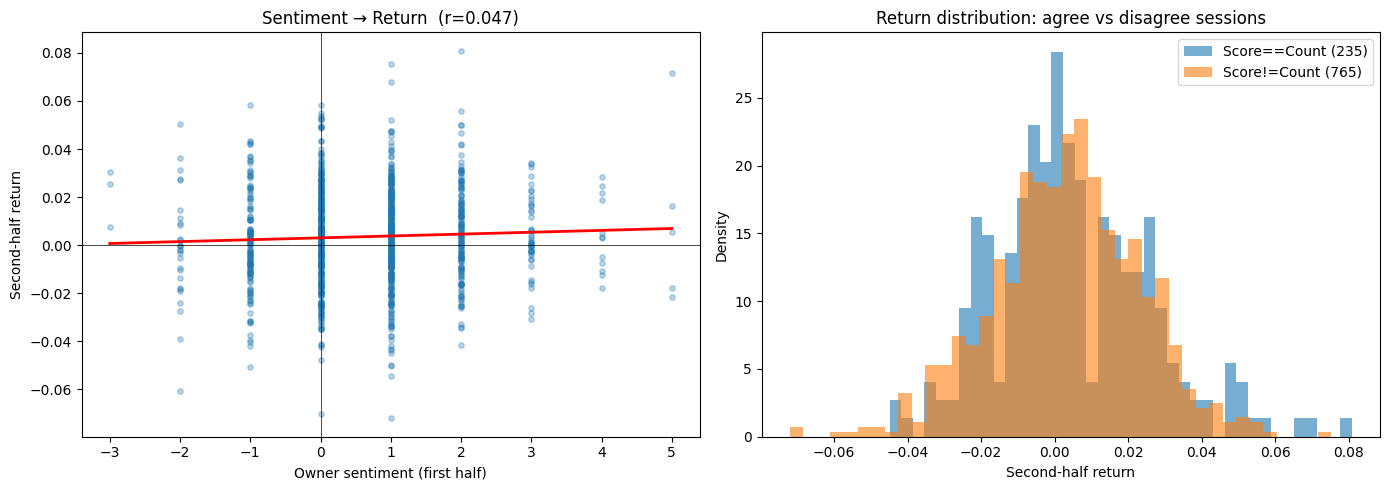

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(val['owner_sentiment'], val['second_half_ret'], alpha=0.3, s=15)
m, b = np.polyfit(val['owner_sentiment'], val['second_half_ret'], 1)
xs = np.linspace(val['owner_sentiment'].min(), val['owner_sentiment'].max(), 100)
ax.plot(xs, m*xs+b, 'r-', lw=2)
ax.set_xlabel('Owner sentiment (first half)')
ax.set_ylabel('Second-half return')
ax.set_title(f'Sentiment → Return  (r={val["owner_sentiment"].corr(val["second_half_ret"]):.3f})')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)

ax = axes[1]
agree_mask = (predictions['predicted_owner_score'] == predictions['predicted_owner_count'])
agree_sessions = predictions[agree_mask]['session']
disagree_sessions = predictions[~agree_mask]['session']

ret_agree    = session_returns.loc[session_returns.index.isin(agree_sessions)]
ret_disagree = session_returns.loc[session_returns.index.isin(disagree_sessions)]

ax.hist(ret_agree,    bins=40, alpha=0.6, label=f'Score==Count ({len(ret_agree)})', density=True)
ax.hist(ret_disagree, bins=40, alpha=0.6, label=f'Score!=Count ({len(ret_disagree)})', density=True)
ax.set_xlabel('Second-half return')
ax.set_ylabel('Density')
ax.set_title('Return distribution: agree vs disagree sessions')
ax.legend()

plt.tight_layout()
plt.savefig('session_company_validation.png', dpi=120)
plt.show()

## 7. Deeper: company-level price trajectory clustering

If all sessions belonging to the same company share similar price trajectory shapes (e.g., always trending up, or always mean-reverting), we can validate our assignments by checking intra-company trajectory similarity.

In [152]:
# Build normalized price trajectories (close / close_at_bar0)
traj = bars_all.pivot(index='session', columns='bar_ix', values='close')
traj_norm = traj.div(traj[0], axis=0)  # starts at 1.0

print('Trajectory matrix shape (sessions x bars):', traj_norm.shape)

# Attach predicted company
traj_norm = traj_norm.merge(predictions[['session','predicted_owner_score']], 
                             left_index=True, right_on='session').set_index('session')
traj_norm.head(3)

Trajectory matrix shape (sessions x bars): (1000, 100)


,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,predicted_owner_score
session,,,,,,,,,,,,,,,,,,,,,
0,1.0,1.003400,1.002900,1.005701,1.004900,1.002700,1.006501,1.007101,1.011601,1.012401,...,1.050905,1.052105,1.051405,1.049605,1.046305,1.050805,1.054205,1.053905,1.052905,Orevex Renewables
1,1.0,0.995005,0.996404,0.994106,0.988912,0.984417,0.992508,0.997003,0.997503,0.999800,...,0.973030,0.971631,0.973629,0.972830,0.969234,0.971032,0.971332,0.973229,0.976326,Strynal Industries
2,1.0,1.006629,1.014060,1.010545,1.011248,1.008738,1.010144,1.013458,1.006528,1.003515,...,1.046600,1.049613,1.047203,1.048810,1.052325,1.054534,1.060360,1.057949,1.053329,Kelvik Power


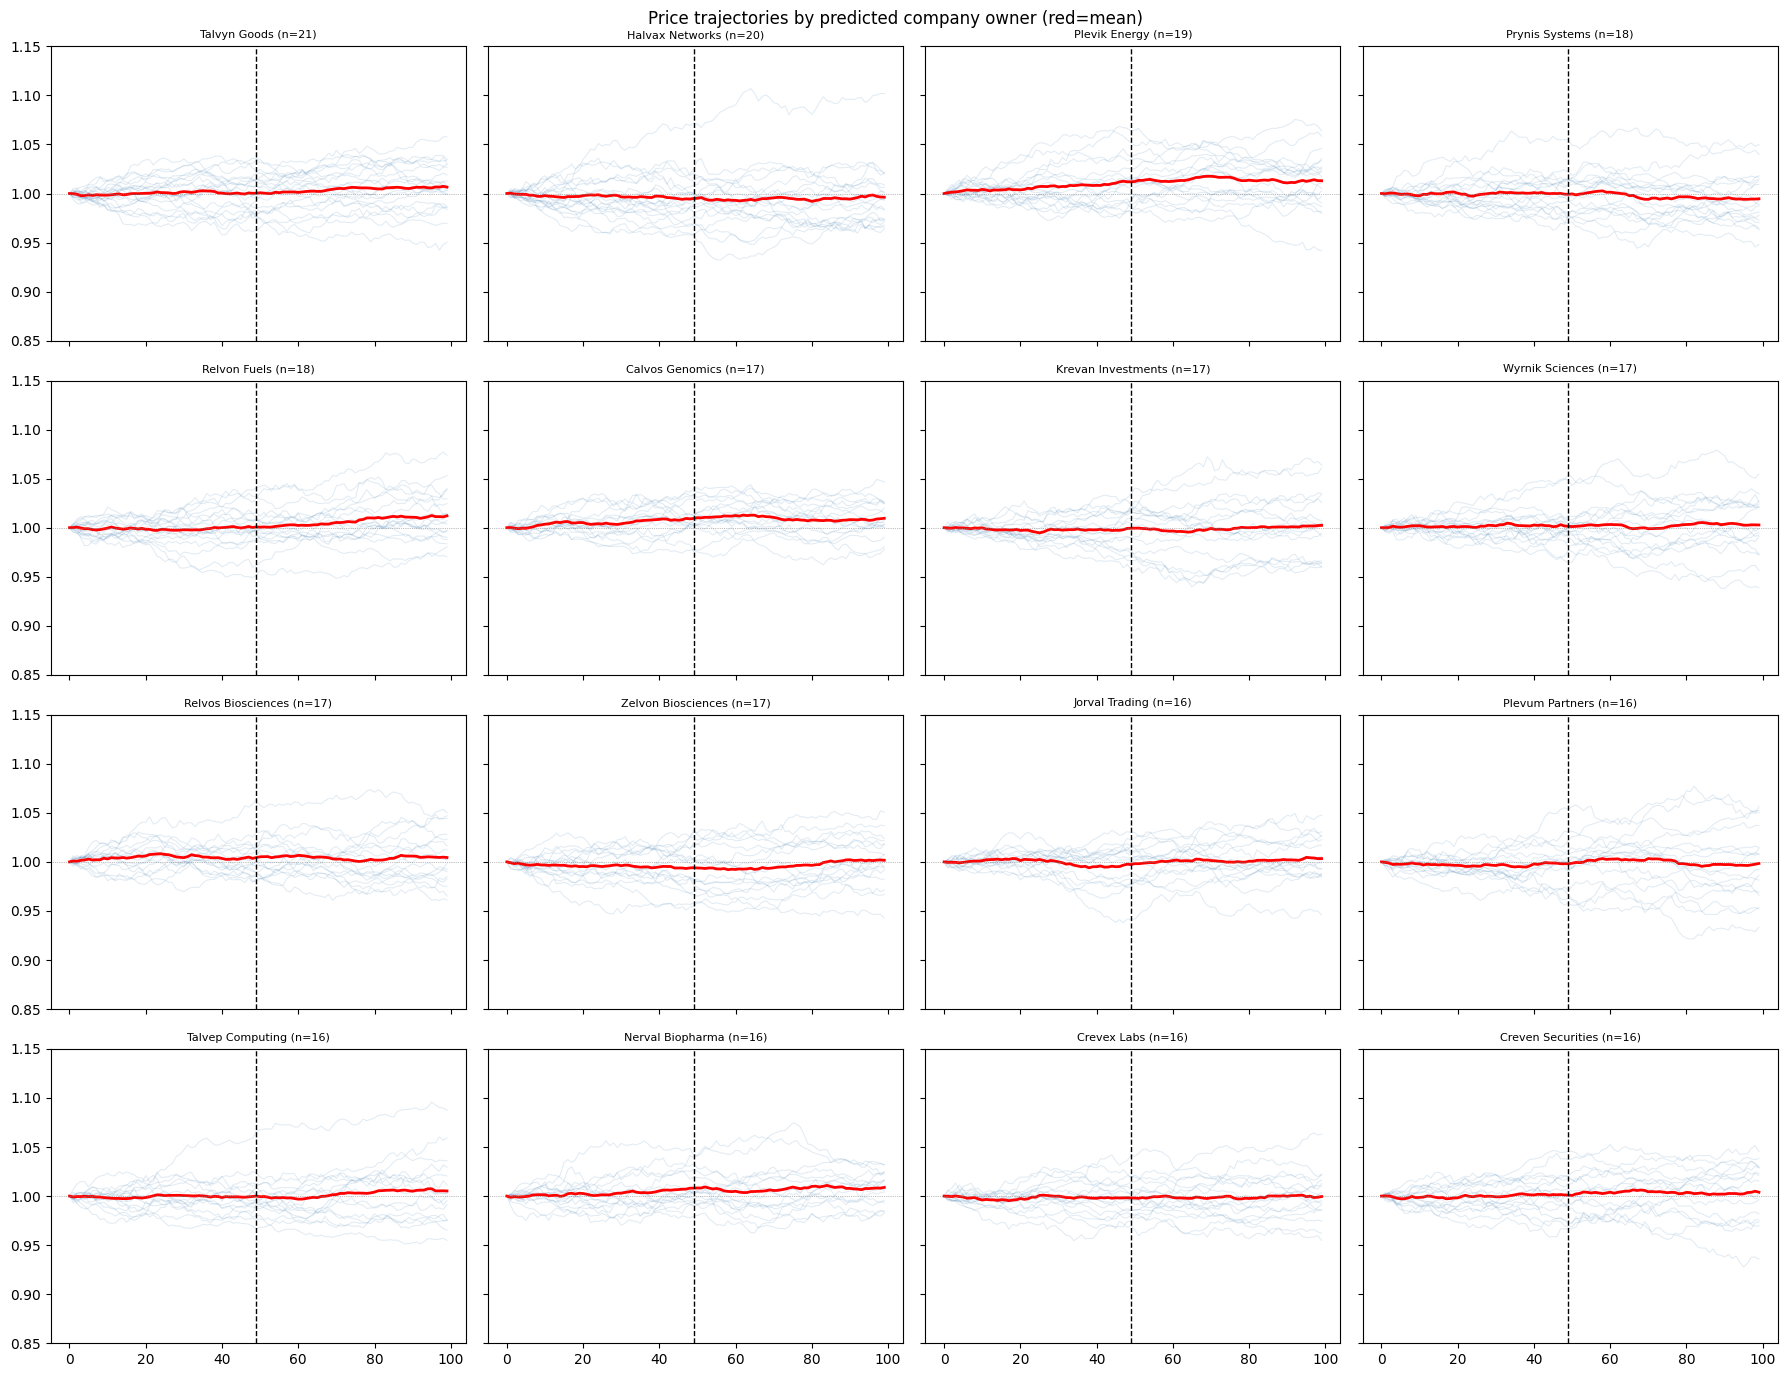

In [153]:
# For top-N companies with enough sessions, plot mean trajectory
company_counts = predictions['predicted_owner_score'].value_counts()
top_companies  = company_counts[company_counts >= 8].index.tolist()[:16]

fig, axes = plt.subplots(4, 4, figsize=(18, 14), sharex=True, sharey=True)
axes = axes.flatten()

bar_cols = [c for c in traj_norm.columns if c != 'predicted_owner_score']

for i, comp in enumerate(top_companies):
    ax = axes[i]
    mask = traj_norm['predicted_owner_score'] == comp
    subset = traj_norm[mask][bar_cols]
    
    for _, row in subset.iterrows():
        ax.plot(bar_cols, row.values, alpha=0.15, lw=0.8, color='steelblue')
    
    mean_traj = subset.mean()
    ax.plot(bar_cols, mean_traj.values, 'r-', lw=2)
    ax.axvline(49, color='k', lw=1, ls='--', label='halfway')
    ax.set_title(f'{comp} (n={mask.sum()})', fontsize=8)
    ax.set_ylim(0.85, 1.15)
    ax.axhline(1, color='gray', lw=0.5, ls=':')

fig.suptitle('Price trajectories by predicted company owner (red=mean)', fontsize=12)
plt.tight_layout()
plt.savefig('company_trajectories.png', dpi=100)
plt.show()

## 8. Volatility fingerprint per company

Some companies might have persistently higher intrabar volatility (e.g., biotech vs utilities). We check if the predicted company assignments show distinct volatility fingerprints.

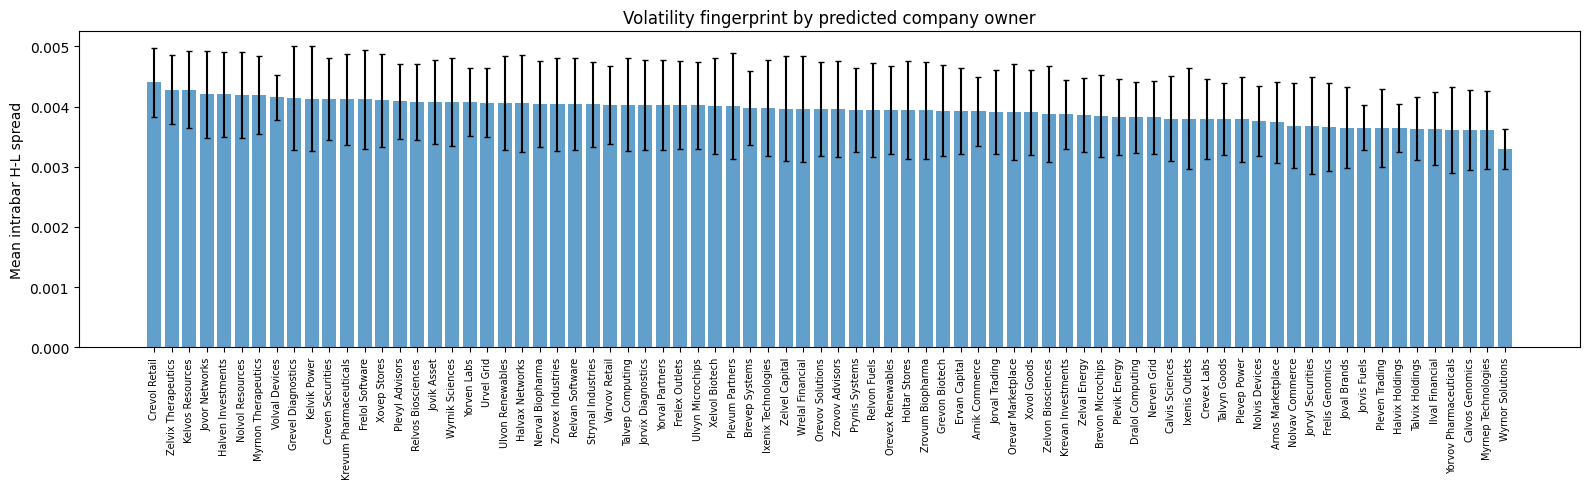

Volatility range: 0.00329 - 0.00440
Volatility std across companies: 0.00019


In [154]:
# Per-session volatility stats
session_vol = bars[['session','vol_hl']].groupby('session')['vol_hl'].mean().reset_index()
session_vol.columns = ['session','mean_vol_hl']

session_vol = session_vol.merge(predictions[['session','predicted_owner_score']], on='session')

company_vol = session_vol.groupby('predicted_owner_score')['mean_vol_hl'].agg(['mean','std','count'])
company_vol = company_vol[company_vol['count'] >= 5].sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
x = range(len(company_vol))
ax.bar(x, company_vol['mean'], yerr=company_vol['std'], capsize=2, alpha=0.7)
ax.set_xticks(list(x))
ax.set_xticklabels(company_vol.index, rotation=90, fontsize=7)
ax.set_ylabel('Mean intrabar H-L spread')
ax.set_title('Volatility fingerprint by predicted company owner')
plt.tight_layout()
plt.savefig('company_volatility.png', dpi=100)
plt.show()

print(f'Volatility range: {company_vol["mean"].min():.5f} - {company_vol["mean"].max():.5f}')
print(f'Volatility std across companies: {company_vol["mean"].std():.5f}')

## 9. Headline timing alignment score

A stronger test: if company X owns the session, its headline bars should have **above-average absolute returns** compared to bars without its headlines.
We compute the *lift* in |ret_k| on headline bars vs non-headline bars, per (session, company).

In [155]:
# For each session, compute baseline mean |ret_1| across all bars
_ret_cols = bars[['session','ret_1','ret_2','ret_15']].copy()
session_baseline = _ret_cols.groupby('session').agg(
    base_abs_ret1=('ret_1', lambda x: x.abs().mean()),
    base_abs_ret2=('ret_2', lambda x: x.abs().mean()),
    base_abs_ret15=('ret_15', lambda x: x.abs().mean()),
).reset_index()

# Merge into session_company_scores
scs = session_company_scores.merge(session_baseline, on='session')

# Lift = (score_on_headline_bars - baseline) / baseline
scs['lift_ret1'] = (scs['score_abs_ret1'] - scs['base_abs_ret1']) / (scs['base_abs_ret1'] + 1e-9)
scs['lift_ret2'] = (scs['score_abs_ret2'] - scs['base_abs_ret2']) / (scs['base_abs_ret2'] + 1e-9)
scs['lift_ret15'] = (scs['score_abs_ret15'] - scs['base_abs_ret15']) / (scs['base_abs_ret15'] + 1e-9)
scs['lift_combined'] = scs['lift_ret1']*0.4 + scs['lift_ret2']*0.35 + scs['lift_ret15']*0.25

# Re-predict using lift score
best_by_lift = (
    scs.sort_values(['session','lift_combined'], ascending=[True,False])
    .groupby('session').first()
    .reset_index()[['session','company','lift_combined','n_headlines']]
    .rename(columns={'company':'predicted_owner_lift'})
)

# Compare all three methods
all_preds = predictions.merge(best_by_lift[['session','predicted_owner_lift']], on='session')
agree_all = (
    (all_preds['predicted_owner_score'] == all_preds['predicted_owner_count']) &
    (all_preds['predicted_owner_score'] == all_preds['predicted_owner_lift'])
).mean()
print(f'All 3 methods agree: {agree_all:.1%}')

agree_score_lift = (all_preds['predicted_owner_score'] == all_preds['predicted_owner_lift']).mean()
agree_count_lift = (all_preds['predicted_owner_count'] == all_preds['predicted_owner_lift']).mean()
print(f'Score vs Lift agree: {agree_score_lift:.1%}')
print(f'Count vs Lift agree: {agree_count_lift:.1%}')

all_preds.head(10)

All 3 methods agree: 19.2%
Score vs Lift agree: 83.9%
Count vs Lift agree: 23.9%


,session,predicted_owner_score,combined_score,n_headlines,predicted_owner_count,predicted_owner_lift
0,0,Orevex Renewables,0.243459,3,Relvos Biosciences,Orevex Renewables
1,1,Strynal Industries,2.345612,2,Jorvis Fuels,Strynal Industries
2,2,Kelvik Power,-0.088188,6,Kelvik Power,Kelvik Power
3,3,Relvan Software,-0.707956,3,Talvix Holdings,Talvix Holdings
4,4,Zelval Energy,0.083460,2,Frelol Software,Zelval Energy
5,5,Urvel Grid,0.105973,1,Nolvol Resources,Urvel Grid
6,6,Halvix Holdings,0.209341,3,Halvix Holdings,Halvix Holdings
7,7,Joval Brands,-0.376077,3,Myrnep Technologies,Joval Brands
8,8,Ilval Financial,-0.019091,4,Ilval Financial,Ilval Financial
9,9,Halvax Networks,1.506782,1,Orevex Renewables,Halvax Networks


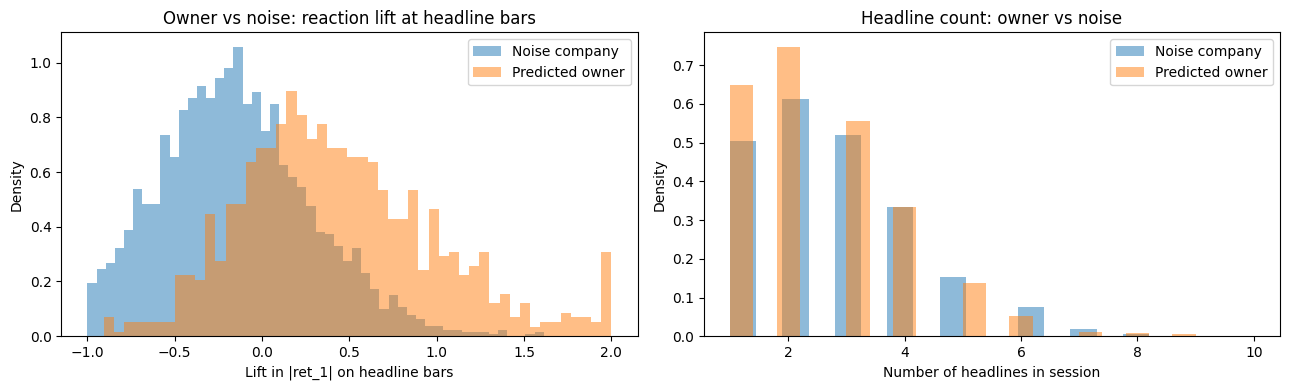

Mean lift_ret1 for predicted owner: 0.44756113042212925
Mean lift_ret1 for noise company:  -0.1447689603722937


In [156]:
# Distribution of lift values for predicted owners vs non-owners
scs_with_pred = scs.merge(best_by_lift[['session','predicted_owner_lift']], on='session')
scs_with_pred['is_owner'] = scs_with_pred['company'] == scs_with_pred['predicted_owner_lift']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for label, grp in scs_with_pred.groupby('is_owner'):
    ax.hist(grp['lift_ret1'].clip(-1, 2), bins=50, alpha=0.5, density=True,
            label='Predicted owner' if label else 'Noise company')
ax.set_xlabel('Lift in |ret_1| on headline bars')
ax.set_ylabel('Density')
ax.set_title('Owner vs noise: reaction lift at headline bars')
ax.legend()

ax = axes[1]
for label, grp in scs_with_pred.groupby('is_owner'):
    ax.hist(grp['n_headlines'], bins=20, alpha=0.5, density=True,
            label='Predicted owner' if label else 'Noise company')
ax.set_xlabel('Number of headlines in session')
ax.set_ylabel('Density')
ax.set_title('Headline count: owner vs noise')
ax.legend()

plt.tight_layout()
plt.savefig('lift_distribution.png', dpi=100)
plt.show()

print('Mean lift_ret1 for predicted owner:', scs_with_pred[scs_with_pred['is_owner']]['lift_ret1'].mean())
print('Mean lift_ret1 for noise company: ', scs_with_pred[~scs_with_pred['is_owner']]['lift_ret1'].mean())

## 10. Final prediction table and ensemble

Combine all signals into a final session→company assignment. When methods disagree, fall back to the one with strongest individual lift signal.

In [157]:
# Ensemble: score each company by multiple signals, pick max
# Normalize each signal across companies within a session
def session_normalize(scs_df, col):
    return scs_df.groupby('session')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-9)
    )

scs['z_n_headlines']   = session_normalize(scs, 'n_headlines')
scs['z_abs_ret1']      = session_normalize(scs, 'score_abs_ret1')
scs['z_abs_ret2']      = session_normalize(scs, 'score_abs_ret2')
scs['z_lift_ret1']     = session_normalize(scs, 'lift_ret1')
scs['z_lift_combined'] = session_normalize(scs, 'lift_combined')

scs['ensemble_score'] = (
    scs['z_n_headlines']   * 0.25 +
    scs['z_abs_ret1']      * 0.20 +
    scs['z_abs_ret2']      * 0.20 +
    scs['z_lift_ret1']     * 0.20 +
    scs['z_lift_combined'] * 0.15
)

final_predictions = (
    scs.sort_values(['session','ensemble_score'], ascending=[True,False])
    .groupby('session').first()
    .reset_index()[['session','company','ensemble_score','n_headlines']]
    .rename(columns={'company':'predicted_company'})
)

print('Final predictions (first 20):')
print(final_predictions.head(20).to_string())
print()
print('Predicted company distribution:')
print(final_predictions['predicted_company'].value_counts().head(20))

Final predictions (first 20):
    session    predicted_company  ensemble_score  n_headlines
0         0    Orevex Renewables        0.651226            3
1         1        Halvav Brands        0.451345            2
2         2         Kelvik Power        0.141421            6
3         3      Talvix Holdings        0.512489            4
4         4        Zelval Energy        0.724330            2
5         5     Nolvol Resources        0.753623            4
6         6      Nolvav Commerce        0.410671            3
7         7  Myrnep Technologies        0.513803            5
8         8      Ilval Financial        0.819256            4
9         9      Halvax Networks        0.684960            1
10       10      Frelis Genomics        0.599222            3
11       11      Wyrnik Sciences        0.740581            3
12       12         Jorvis Fuels        0.421000            4
13       13    Jorvyl Securities        0.706136            2
14       14      Frelis Genomics        

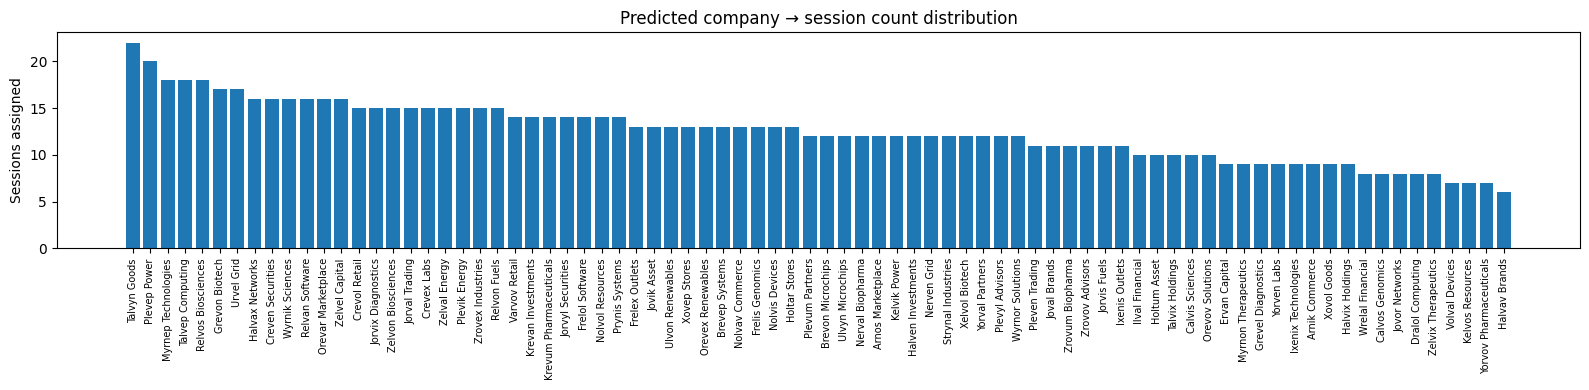

Companies with ≥1 session: 80 / 80
Sessions with unique company assignment: 1000


In [158]:
# How many sessions are assigned to each company?
fig, ax = plt.subplots(figsize=(16, 4))
vc = final_predictions['predicted_company'].value_counts()
ax.bar(range(len(vc)), vc.values)
ax.set_xticks(range(len(vc)))
ax.set_xticklabels(vc.index, rotation=90, fontsize=7)
ax.set_ylabel('Sessions assigned')
ax.set_title('Predicted company → session count distribution')
plt.tight_layout()
plt.savefig('company_session_distribution.png', dpi=100)
plt.show()

n_companies_used = (vc > 0).sum()
print(f'Companies with ≥1 session: {n_companies_used} / {len(all_companies)}')
print(f'Sessions with unique company assignment: {len(final_predictions)}')

Score margin stats (top1 - top2 company):
count    998.000000
mean       0.559830
std        0.390375
min        0.000000
25%        0.229489
50%        0.511898
75%        0.812801
max        1.737337
Name: score_margin, dtype: float64


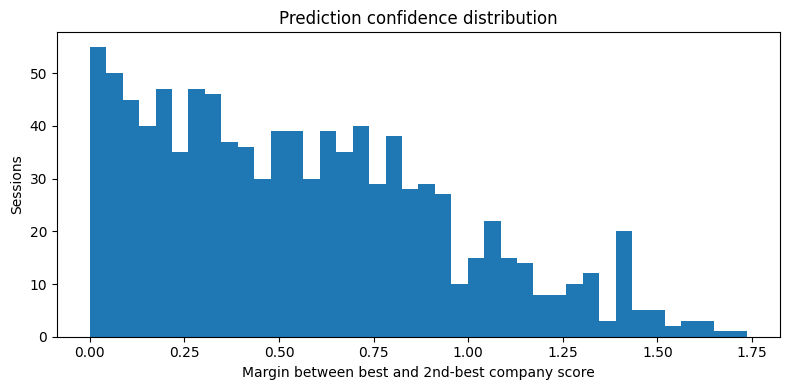

In [159]:
# Confidence: how much does the top company beat the second?
top2 = (
    scs.sort_values(['session','ensemble_score'], ascending=[True,False])
    .groupby('session')['ensemble_score'].apply(lambda x: x.iloc[0] - x.iloc[1] if len(x) > 1 else x.iloc[0])
    .rename('score_margin')
    .reset_index()
)

final_predictions = final_predictions.merge(top2, on='session')

print('Score margin stats (top1 - top2 company):')
print(final_predictions['score_margin'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(final_predictions['score_margin'], bins=40)
ax.set_xlabel('Margin between best and 2nd-best company score')
ax.set_ylabel('Sessions')
ax.set_title('Prediction confidence distribution')
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=100)
plt.show()

## 11. Validate: do same-company sessions share a mean-reversion / trend structure?

If our company assignments are good, sessions assigned to the same company should have more similar trajectories than random.

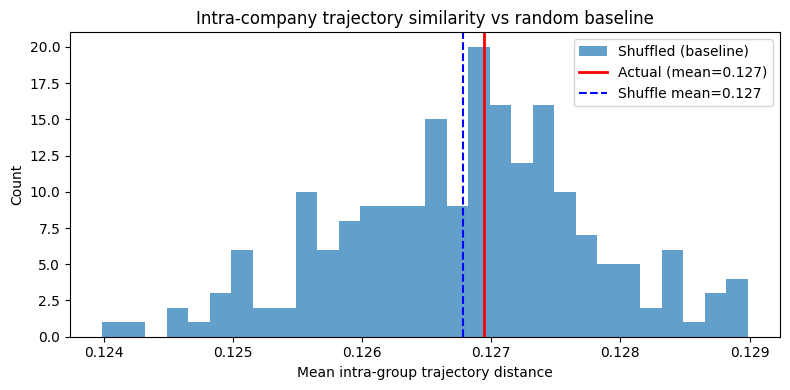

Real intra-company mean distance: 0.1269
Shuffle mean distance: 0.1268
Approx p-value (lower is better): 0.535


In [160]:
from scipy.spatial.distance import pdist

# Use only the second-half (unseen) trajectory for this check
traj_unseen = bars_unseen.pivot(index='session', columns='bar_ix', values='close')

# Normalize by first unseen bar
traj_unseen_norm = traj_unseen.div(traj_unseen.iloc[:, 0], axis=0)

# Merge company assignments
traj_df = traj_unseen_norm.merge(
    final_predictions[['session','predicted_company']], 
    left_index=True, right_on='session'
).set_index('session')

company_cols = [c for c in traj_df.columns if c != 'predicted_company']

# For each company with enough sessions, compute intra-company pairwise distance
intra_dists = {}
for comp, grp in traj_df.groupby('predicted_company'):
    if len(grp) >= 4:
        mat = grp[company_cols].values
        intra_dists[comp] = pdist(mat, metric='euclidean').mean()

# Shuffle baseline: random groups of same size
rng = np.random.default_rng(42)
n_shuffles = 200
shuffle_dists = []
sizes = [len(grp) for _, grp in traj_df.groupby('predicted_company') if len(grp) >= 4]
traj_mat_full = traj_df[company_cols].values
for _ in range(n_shuffles):
    idx = rng.permutation(len(traj_mat_full))
    pos = 0
    d_list = []
    for sz in sizes:
        chunk = traj_mat_full[idx[pos:pos+sz]]
        if sz >= 2:
            d_list.append(pdist(chunk, metric='euclidean').mean())
        pos += sz
    shuffle_dists.append(np.mean(d_list))

real_mean = np.mean(list(intra_dists.values()))
shuffle_mean = np.mean(shuffle_dists)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(shuffle_dists, bins=30, alpha=0.7, label='Shuffled (baseline)')
ax.axvline(real_mean, color='red', lw=2, label=f'Actual (mean={real_mean:.3f})')
ax.axvline(shuffle_mean, color='blue', lw=1.5, ls='--', label=f'Shuffle mean={shuffle_mean:.3f}')
ax.set_xlabel('Mean intra-group trajectory distance')
ax.set_ylabel('Count')
ax.set_title('Intra-company trajectory similarity vs random baseline')
ax.legend()
plt.tight_layout()
plt.savefig('trajectory_similarity_validation.png', dpi=100)
plt.show()

pvalue_approx = np.mean(np.array(shuffle_dists) <= real_mean)
print(f'Real intra-company mean distance: {real_mean:.4f}')
print(f'Shuffle mean distance: {shuffle_mean:.4f}')
print(f'Approx p-value (lower is better): {pvalue_approx:.3f}')

## 12. Summary of findings

## 13. Word-level predictive power

Not all words carry equal signal. We extract the **content words** (everything after the company name) from each headline and measure:
- **mean_ret5**: average signed 5-bar return following headlines containing this word → direction signal
- **mean_abs_ret5**: average absolute 5-bar return → volatility/magnitude signal
- **t-statistic** for mean_ret5 ≠ 0 → statistical significance

Words like `breakthrough`, `merger`, `expands` vs `withdraws`, `warns`, `loses` are hypothesised to matter.

In [162]:
import re
from scipy import stats as sp_stats

def get_content_words(headline):
    words = headline.lower().split()[2:]
    return [re.sub(r'[^a-z]', '', w) for w in words if len(re.sub(r'[^a-z]', '', w)) > 3]

h_words = h.copy()
h_words['content_words'] = h_words['headline'].apply(get_content_words)

word_rows = h_words.explode('content_words').rename(columns={'content_words': 'word'})
word_rows = word_rows.dropna(subset=['word', 'ret_1', 'ret_15'])
word_rows = word_rows[word_rows['word'].str.len() > 3]

# T-test per word: is mean_ret15 significantly non-zero?
tstat_rows = []
for word, grp in word_rows.groupby('word'):
    if len(grp) < 10:
        continue
    r1 = grp['ret_1'].dropna()
    r15 = grp['ret_15'].dropna()
    t1, p1 = sp_stats.ttest_1samp(r1, 0)
    t15, p15 = sp_stats.ttest_1samp(r15, 0)
    tstat_rows.append({
        'word': word, 'count': len(grp),
        'mean_ret1': r1.mean(), 'mean_abs_ret1': r1.abs().mean(),
        'mean_ret2': grp['ret_2'].mean(), 'mean_abs_ret2': grp['ret_2'].abs().mean(),
        'mean_ret3': grp['ret_3'].mean() if 'ret_3' in grp else np.nan,
        'mean_ret15': r15.mean(), 'mean_abs_ret15': r15.abs().mean(),
        't_ret1': t1, 'p_ret1': p1, 't_ret15': t15, 'p_ret15': p15,
    })

word_stats_df = pd.DataFrame(tstat_rows)
n_words = len(word_stats_df)
print(f'Words with >= 10 appearances: {n_words}')
print()
print('Top POSITIVE words by mean 5-bar return (p < 0.05):')
pos = word_stats_df[word_stats_df['p_ret15'] < 0.05].nlargest(20, 'mean_ret15')
print(pos[['word','count','mean_ret1','mean_ret15','t_ret15','p_ret15']].to_string(index=False))
print()
print('Top NEGATIVE words by mean 5-bar return (p < 0.05):')
neg = word_stats_df[word_stats_df['p_ret15'] < 0.05].nsmallest(20, 'mean_ret15')
print(neg[['word','count','mean_ret1','mean_ret15','t_ret15','p_ret15']].to_string(index=False))


Words with >= 10 appearances: 227

Top POSITIVE words by mean 5-bar return (p < 0.05):
          word  count  mean_ret1  mean_ret15  t_ret15      p_ret15
  breakthrough    214   0.000484    0.005214 6.176351 3.280050e-09
    consortium    261   0.000727    0.004218 5.979622 7.357066e-09
 international    261   0.000727    0.004218 5.979622 7.357066e-09
     multiyear    140   0.000387    0.004199 4.221356 4.361741e-05
   partnership    140   0.000387    0.004199 4.221356 4.361741e-05
         signs    140   0.000387    0.004199 4.221356 4.361741e-05
    strengthen    237   0.000469    0.003997 4.713872 4.156601e-06
       expands    183   0.000274    0.003917 4.373929 2.050724e-05
          into    183   0.000274    0.003917 4.373929 2.050724e-05
       buyback    239   0.000356    0.003804 5.181979 4.682877e-07
         share    239   0.000356    0.003804 5.181979 4.682877e-07
      launches    237   0.000221    0.003673 4.825235 2.510920e-06
nextgeneration    237   0.000221    0.0036

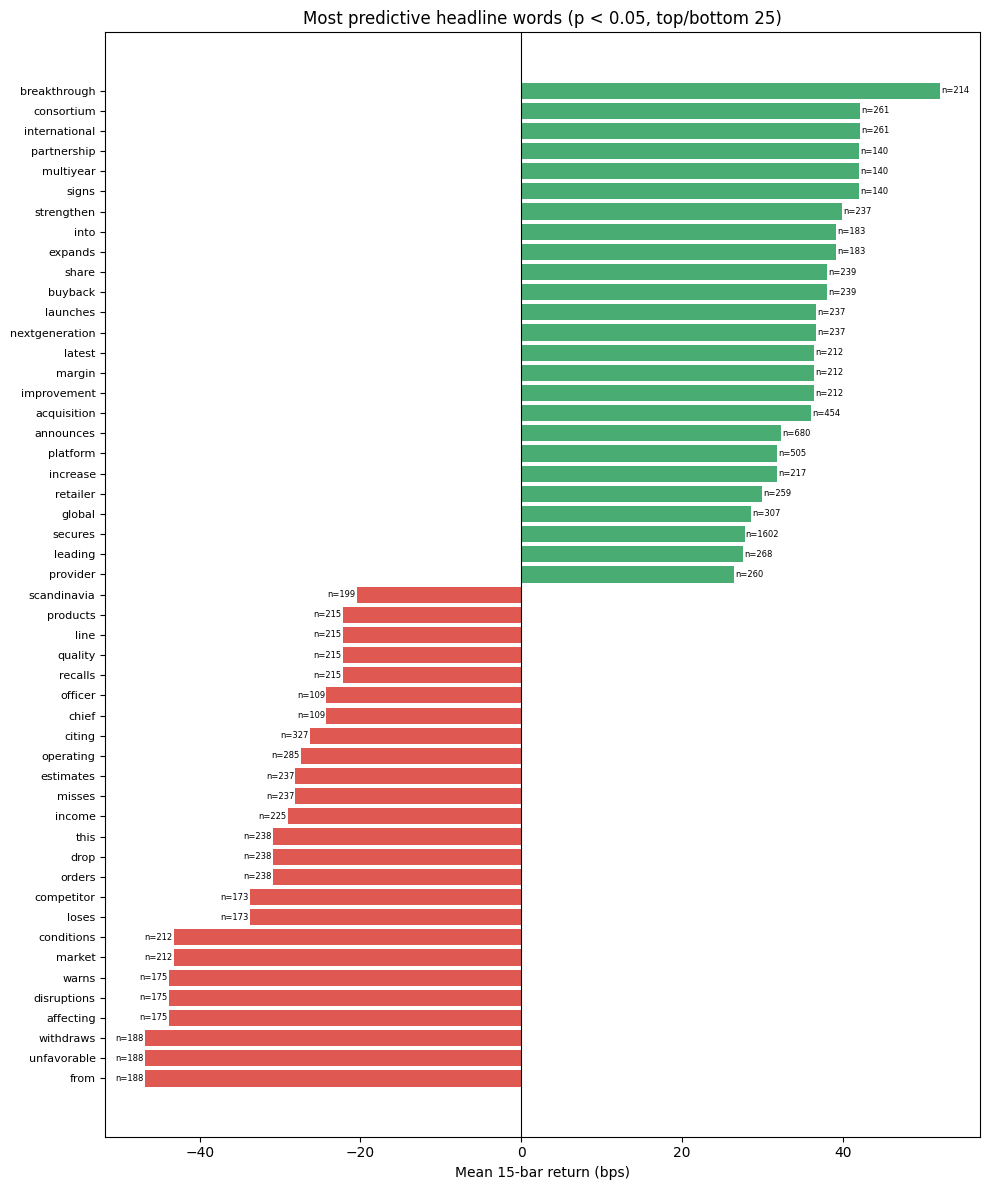

In [164]:
sig = word_stats_df[word_stats_df['p_ret15'] < 0.05].copy()
sig_sorted = sig.sort_values('mean_ret15')
n_show = 25
plot_words = pd.concat([sig_sorted.head(n_show), sig_sorted.tail(n_show)])
colors = ['#d73027' if v < 0 else '#1a9850' for v in plot_words['mean_ret15']]

fig, ax = plt.subplots(figsize=(10, 12))
bars_plot = ax.barh(plot_words['word'], plot_words['mean_ret15'] * 1e4, color=colors, alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Mean 15-bar return (bps)')
ax.set_title('Most predictive headline words (p < 0.05, top/bottom 25)')
ax.tick_params(axis='y', labelsize=8)
for bar, (_, row) in zip(bars_plot, plot_words.iterrows()):
    x = bar.get_width()
    ax.text(x + (0.15 if x >= 0 else -0.15), bar.get_y() + bar.get_height()/2,
            f'n={int(row["count"])}', va='center', ha='left' if x >= 0 else 'right', fontsize=6)
plt.tight_layout()
plt.savefig('word_impact_chart.png', dpi=120)
plt.show()


### 13b. Spotlight words — owner-matched headlines only

Repeat the word-level analysis filtering to **only headlines where the headline company matches the predicted session owner**. 
This removes noise-company headlines from the signal, so any word effect we see is cleaner and more likely causal.

In [165]:
# Only keep headline rows where the company matches the predicted session owner
h_owner = h.merge(final_predictions[['session','predicted_company']], on='session')
h_owner = h_owner[h_owner['company'] == h_owner['predicted_company']].copy()
print(f'Total headline rows         : {len(h)}')
print(f'Owner-matched headline rows : {len(h_owner)}')
print(f'Fraction kept               : {len(h_owner)/len(h):.1%}')

# Explode to one word per row, same as before
h_owner['content_words'] = h_owner['headline'].apply(get_content_words)
word_rows_owner = h_owner.explode('content_words').rename(columns={'content_words': 'word'})
word_rows_owner = word_rows_owner.dropna(subset=['word', 'ret_1', 'ret_15'])
word_rows_owner = word_rows_owner[word_rows_owner['word'].str.len() > 3]

tstat_owner = []
for word, grp in word_rows_owner.groupby('word'):
    if len(grp) < 5:
        continue
    r1 = grp['ret_1'].dropna()
    r5 = grp['ret_15'].dropna()
    t1, p1 = sp_stats.ttest_1samp(r1, 0)
    t5, p5 = sp_stats.ttest_1samp(r5, 0)
    tstat_owner.append({
        'word': word, 'count': len(grp),
        'mean_ret1': r1.mean(), 'mean_abs_ret1': r1.abs().mean(),
        'mean_ret2': grp['ret_2'].mean(), 'mean_abs_ret2': grp['ret_2'].abs().mean(),
        'mean_ret3': grp['ret_3'].mean() if 'ret_3' in grp.columns else np.nan,
        'mean_ret15': r5.mean(), 'mean_abs_ret15': r5.abs().mean(),
        't_ret1': t1, 'p_ret1': p1, 't_ret15': t5, 'p_ret15': p5,
    })

word_stats_owner = pd.DataFrame(tstat_owner)
print(f'Words with >= 5 owner-matched appearances: {len(word_stats_owner)}')
print()
print('Top POSITIVE words (owner-matched, p < 0.10):')
pos_o = word_stats_owner[word_stats_owner['p_ret15'] < 0.10].nlargest(20, 'mean_ret15')
print(pos_o[['word','count','mean_ret1','mean_ret15','t_ret15','p_ret15']].to_string(index=False))
print()
print('Top NEGATIVE words (owner-matched, p < 0.10):')
neg_o = word_stats_owner[word_stats_owner['p_ret15'] < 0.10].nsmallest(20, 'mean_ret15')
print(neg_o[['word','count','mean_ret1','mean_ret15','t_ret15','p_ret15']].to_string(index=False))


Total headline rows         : 9740
Owner-matched headline rows : 2901
Fraction kept               : 29.8%
Words with >= 5 owner-matched appearances: 214

Top POSITIVE words (owner-matched, p < 0.10):
         word  count  mean_ret1  mean_ret15  t_ret15  p_ret15
      details      9   0.000749    0.009778 2.447868 0.040070
       merger      9   0.000749    0.009778 2.447868 0.040070
    potential      9   0.000749    0.009778 2.447868 0.040070
        talks      9   0.000749    0.009778 2.447868 0.040070
  undisclosed      9   0.000749    0.009778 2.447868 0.040070
 breakthrough     58   0.000716    0.006856 3.919269 0.000241
      leading     74   0.001009    0.006217 4.429128 0.000033
    multiyear     39   0.000712    0.005448 2.897113 0.006218
  partnership     39   0.000712    0.005448 2.897113 0.006218
        signs     39   0.000712    0.005448 2.897113 0.006218
      expands     47   0.001037    0.005357 2.580197 0.013133
         into     47   0.001037    0.005357 2.580197 0.0

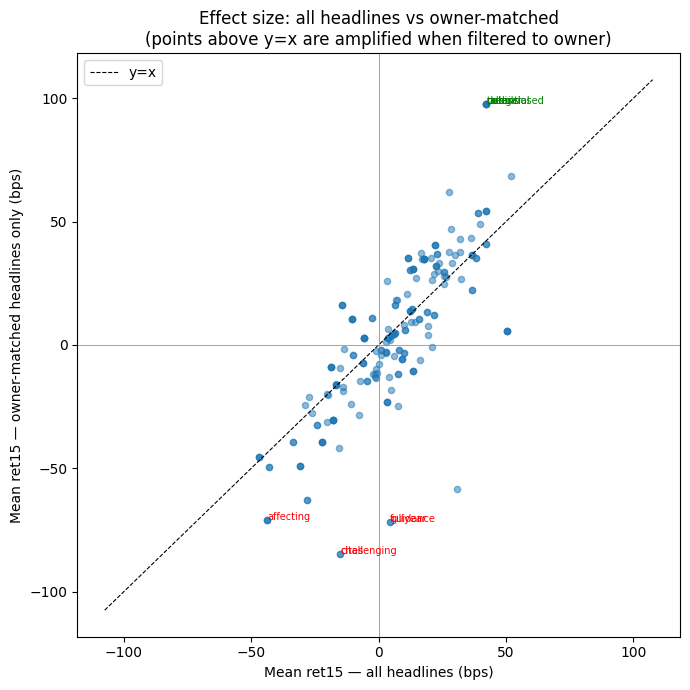

Words most amplified by owner-filter (strongest owner signal):
        word  ret15_all  ret15_owner  amplification
     details   0.004228     0.009778       2.312433
      merger   0.004228     0.009778       2.312433
   potential   0.004228     0.009778       2.312433
       talks   0.004228     0.009778       2.312433
 undisclosed   0.004228     0.009778       2.312433
breakthrough   0.005214     0.006856       1.314723
     leading   0.002757     0.006217       2.255058
   multiyear   0.004199     0.005448       1.297673
 partnership   0.004199     0.005448       1.297673
       signs   0.004199     0.005448       1.297673


In [167]:
# Compare effect sizes: all headlines vs owner-matched only
common_words = set(word_stats_df['word']) & set(word_stats_owner['word'])
merged_compare = (
    word_stats_df[word_stats_df['word'].isin(common_words)][['word','mean_ret15','p_ret15']]
    .rename(columns={'mean_ret15':'ret15_all', 'p_ret15':'p_all'})
    .merge(
        word_stats_owner[word_stats_owner['word'].isin(common_words)][['word','mean_ret15','p_ret15']]
        .rename(columns={'mean_ret15':'ret15_owner', 'p_ret15':'p_owner'}),
        on='word'
    )
)
merged_compare['amplification'] = merged_compare['ret15_owner'] / (merged_compare['ret15_all'].abs() + 1e-9)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(merged_compare['ret15_all'] * 1e4, merged_compare['ret15_owner'] * 1e4, alpha=0.5, s=20)
lim = max(merged_compare[['ret15_all','ret15_owner']].abs().max()) * 1e4 * 1.1
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, label='y=x')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
# Label outliers
for _, row in merged_compare.nlargest(5, 'ret15_owner').iterrows():
    ax.annotate(row['word'], (row['ret15_all']*1e4, row['ret15_owner']*1e4), fontsize=7, color='green')
for _, row in merged_compare.nsmallest(5, 'ret15_owner').iterrows():
    ax.annotate(row['word'], (row['ret15_all']*1e4, row['ret15_owner']*1e4), fontsize=7, color='red')
ax.set_xlabel('Mean ret15 — all headlines (bps)')
ax.set_ylabel('Mean ret15 — owner-matched headlines only (bps)')
ax.set_title('Effect size: all headlines vs owner-matched\n(points above y=x are amplified when filtered to owner)')
ax.legend()
plt.tight_layout()
plt.savefig('word_owner_vs_all.png', dpi=120)
plt.show()

print('Words most amplified by owner-filter (strongest owner signal):')
print(merged_compare[merged_compare['ret15_owner'] > 0].nlargest(10, 'ret15_owner')[['word','ret15_all','ret15_owner','amplification']].to_string(index=False))


Spotlight words — OWNER-MATCHED headlines only:
              count  mean_ret1  mean_ret15  mean_abs_ret15   t_ret15   p_ret15
word                                                                          
breakthrough     58   0.000716    0.006856        0.011438  3.919269  0.000241
merger            9   0.000749    0.009778        0.009933  2.447868  0.040070
expands          47   0.001037    0.005357        0.011831  2.580197  0.013133
improvement      68   0.000611    0.003637        0.010117  2.496154  0.015022
acquisition     147   0.000838    0.004355        0.010159  4.301850  0.000031
withdraws        51  -0.000462   -0.004552        0.009912 -2.949308  0.004833
competitor       62  -0.001009   -0.003927        0.012484 -2.117788  0.038277
loses            62  -0.001009   -0.003927        0.012484 -2.117788  0.038277
warns            52  -0.000762   -0.007096        0.010231 -4.740127  0.000018
concerns        117  -0.000897   -0.003116        0.010459 -2.694289  0.008101
robu

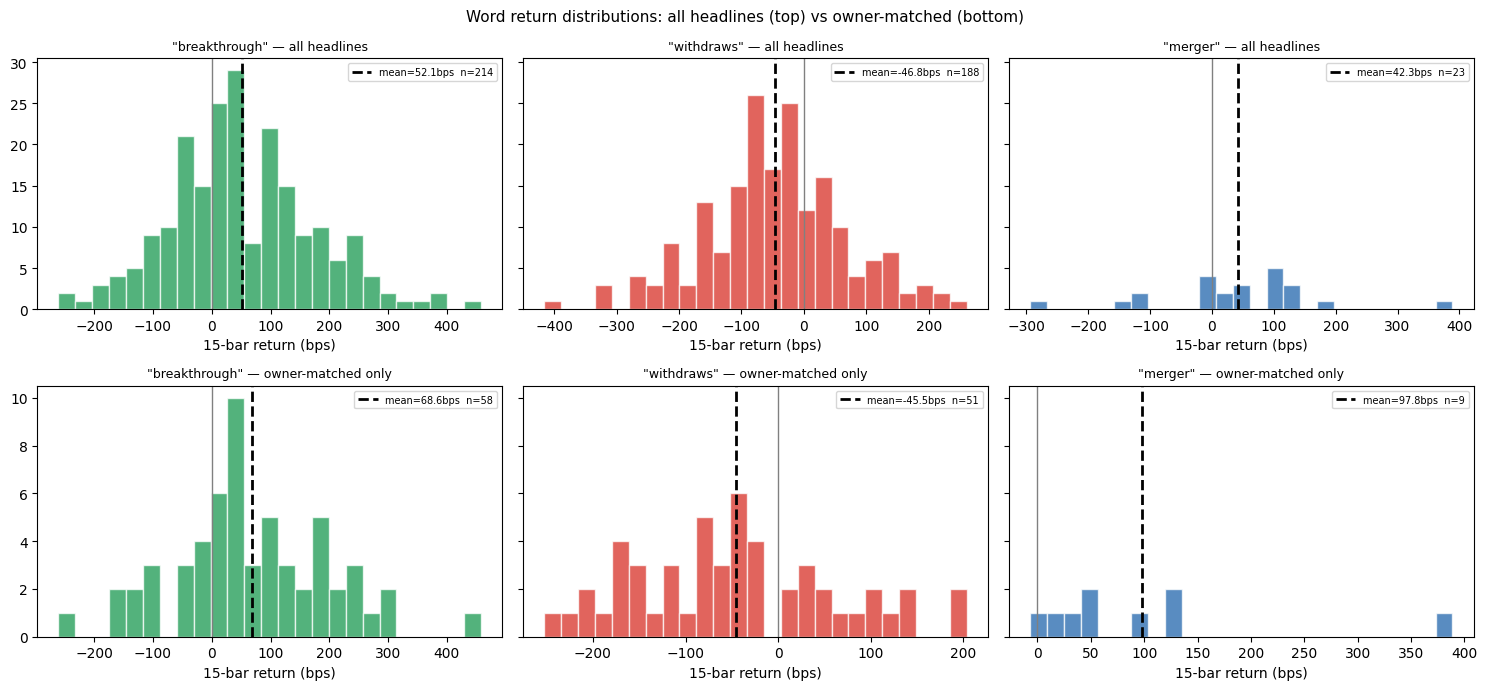

In [169]:
# Spotlight distributions — owner-matched only
spotlight_words_check = [
    'breakthrough', 'merger', 'expands', 'improvement', 'acquisition',
    'withdraws', 'competitor', 'loses', 'warns', 'concerns',
    'robust', 'increase', 'decline', 'record', 'partnership'
]
spotlight_owner = (
    word_stats_owner[word_stats_owner['word'].isin(spotlight_words_check)]
    .set_index('word').reindex(spotlight_words_check).dropna()
)
print('Spotlight words — OWNER-MATCHED headlines only:')
print(spotlight_owner[['count','mean_ret1','mean_ret15','mean_abs_ret15','t_ret15','p_ret15']].to_string())
print()

# Side-by-side distributions for 3 words: all vs owner
highlight3 = [('breakthrough', '#1a9850'), ('withdraws', '#d73027'), ('merger', '#2166ac')]
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey='row')
for j, (word, color) in enumerate(highlight3):
    vals_all   = word_rows[word_rows['word'] == word]['ret_15'].dropna() * 1e4
    vals_owner = word_rows_owner[word_rows_owner['word'] == word]['ret_15'].dropna() * 1e4
    for ax, vals, label in [
        (axes[0, j], vals_all,   'all headlines'),
        (axes[1, j], vals_owner, 'owner-matched only'),
    ]:
        ax.hist(vals, bins=25, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(vals.mean(), color='black', lw=2, ls='--',
                   label=f'mean={vals.mean():.1f}bps  n={len(vals)}')
        ax.axvline(0, color='gray', lw=1)
        ax.set_title(f'"{word}" — {label}', fontsize=9)
        ax.set_xlabel('15-bar return (bps)')
        ax.legend(fontsize=7)
plt.suptitle('Word return distributions: all headlines (top) vs owner-matched (bottom)', fontsize=11)
plt.tight_layout()
plt.savefig('word_owner_distributions.png', dpi=120)
plt.show()


Spotlight words:
              count  mean_ret1  mean_ret15  mean_abs_ret15   t_ret15       p_ret15
word                                                                              
breakthrough    214   0.000484    0.005214        0.010231  6.176351  3.280050e-09
merger           23   0.000747    0.004228        0.010197  1.527870  1.407957e-01
expands         183   0.000274    0.003917        0.010041  4.373929  2.050724e-05
improvement     212   0.000508    0.003647        0.010470  3.982110  9.399540e-05
acquisition     454   0.000434    0.003607        0.009983  6.217390  1.148916e-09
withdraws       188  -0.000329   -0.004678        0.009721 -5.595953  7.713511e-08
competitor      173  -0.000444   -0.003370        0.011601 -3.183028  1.729958e-03
loses           173  -0.000444   -0.003370        0.011601 -3.183028  1.729958e-03
warns           175  -0.000361   -0.004386        0.010206 -4.745776  4.315572e-06
concerns        347  -0.000413   -0.002009        0.009865 -3.058597  

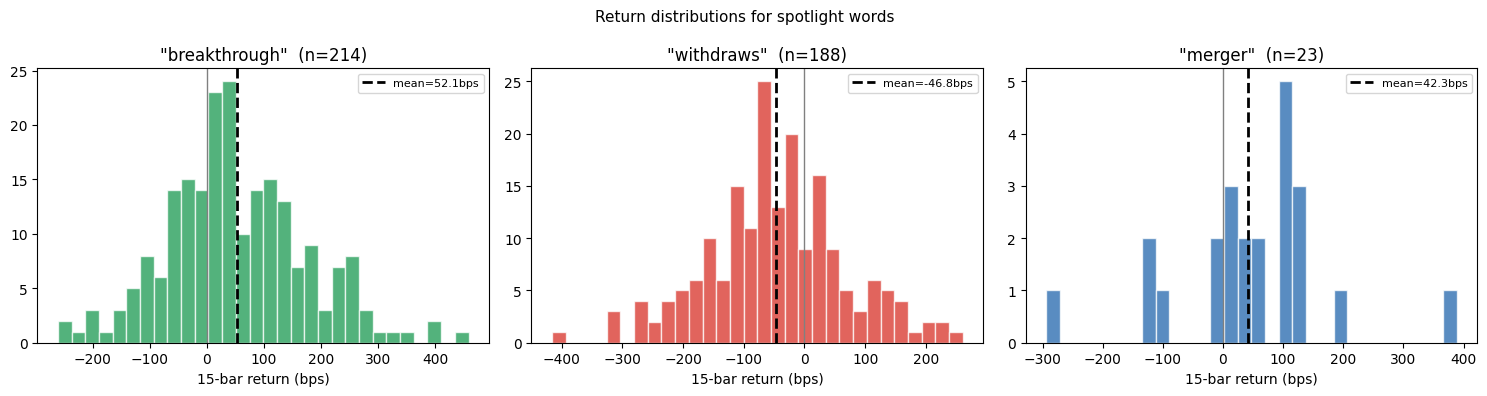

In [170]:
spotlight_words = [
    'breakthrough', 'merger', 'expands', 'improvement', 'acquisition',
    'withdraws', 'competitor', 'loses', 'warns', 'concerns',
    'robust', 'increase', 'decline', 'record', 'partnership'
]

spotlight = word_stats_df[word_stats_df['word'].isin(spotlight_words)].set_index('word').reindex(spotlight_words).dropna()
print('Spotlight words:')
print(spotlight[['count','mean_ret1','mean_ret15','mean_abs_ret15','t_ret15','p_ret15']].to_string())
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
highlight = [('breakthrough', '#1a9850'), ('withdraws', '#d73027'), ('merger', '#2166ac')]
for ax, (word, color) in zip(axes, highlight):
    vals = word_rows[word_rows['word'] == word]['ret_15'].dropna() * 1e4
    ax.hist(vals, bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(vals.mean(), color='black', lw=2, ls='--', label=f'mean={vals.mean():.1f}bps')
    ax.axvline(0, color='gray', lw=1)
    ax.set_title(f'"{word}"  (n={len(vals)})')
    ax.set_xlabel('15-bar return (bps)')
    ax.legend(fontsize=8)
plt.suptitle('Return distributions for spotlight words', fontsize=11)
plt.tight_layout()
plt.savefig('word_return_distributions.png', dpi=120)
plt.show()


In [171]:
# Build a data-driven sentiment lexicon from significant words
sig_pos = word_stats_df[(word_stats_df['p_ret15'] < 0.05) & (word_stats_df['mean_ret15'] > 0)]
sig_neg = word_stats_df[(word_stats_df['p_ret15'] < 0.05) & (word_stats_df['mean_ret15'] < 0)]

LEARNED_POS = sig_pos.nlargest(30, 'mean_ret15')['word'].tolist()
LEARNED_NEG = sig_neg.nsmallest(30, 'mean_ret15')['word'].tolist()

print('Learned POSITIVE keywords:', LEARNED_POS)
print()
print('Learned NEGATIVE keywords:', LEARNED_NEG)

def learned_sentiment(text):
    words = set(get_content_words(text))
    return sum(1 for w in LEARNED_POS if w in words) - sum(1 for w in LEARNED_NEG if w in words)

headlines['learned_sentiment'] = headlines['headline'].apply(learned_sentiment)

h3 = headlines.merge(final_predictions[['session','predicted_company']], on='session')
owner_learned_sent = (
    h3[h3['company'] == h3['predicted_company']]
    .groupby('session')['learned_sentiment'].sum()
    .rename('owner_learned_sentiment')
)
owner_orig_sent = (
    h3[h3['company'] == h3['predicted_company']]
    .groupby('session')['sentiment'].sum()
    .rename('owner_orig_sentiment')
)

val2 = final_predictions.merge(owner_learned_sent, on='session').merge(owner_orig_sent, on='session').merge(session_returns, on='session')

corr_orig    = val2['owner_orig_sentiment'].corr(val2['second_half_ret'])
corr_learned = val2['owner_learned_sentiment'].corr(val2['second_half_ret'])

print()
print('Correlation with 2nd-half return:')
print(f'  Hand-crafted sentiment : {corr_orig:.4f}')
print(f'  Data-driven sentiment  : {corr_learned:.4f}')
print(f'  Improvement            : {corr_learned - corr_orig:+.4f}')


Learned POSITIVE keywords: ['breakthrough', 'consortium', 'international', 'multiyear', 'partnership', 'signs', 'strengthen', 'expands', 'into', 'buyback', 'share', 'launches', 'nextgeneration', 'improvement', 'latest', 'margin', 'acquisition', 'announces', 'platform', 'increase', 'retailer', 'global', 'secures', 'leading', 'provider', 'major', 'program', 'record', 'yearoveryear', 'markets']

Learned NEGATIVE keywords: ['from', 'unfavorable', 'withdraws', 'affecting', 'disruptions', 'warns', 'conditions', 'market', 'competitor', 'loses', 'drop', 'orders', 'this', 'income', 'estimates', 'misses', 'operating', 'citing', 'chief', 'officer', 'line', 'products', 'quality', 'recalls', 'scandinavia', 'concerns', 'decline', 'costs', 'margins', 'pressuring']

Correlation with 2nd-half return:
  Hand-crafted sentiment : 0.0471
  Data-driven sentiment  : -0.0090
  Improvement            : -0.0562


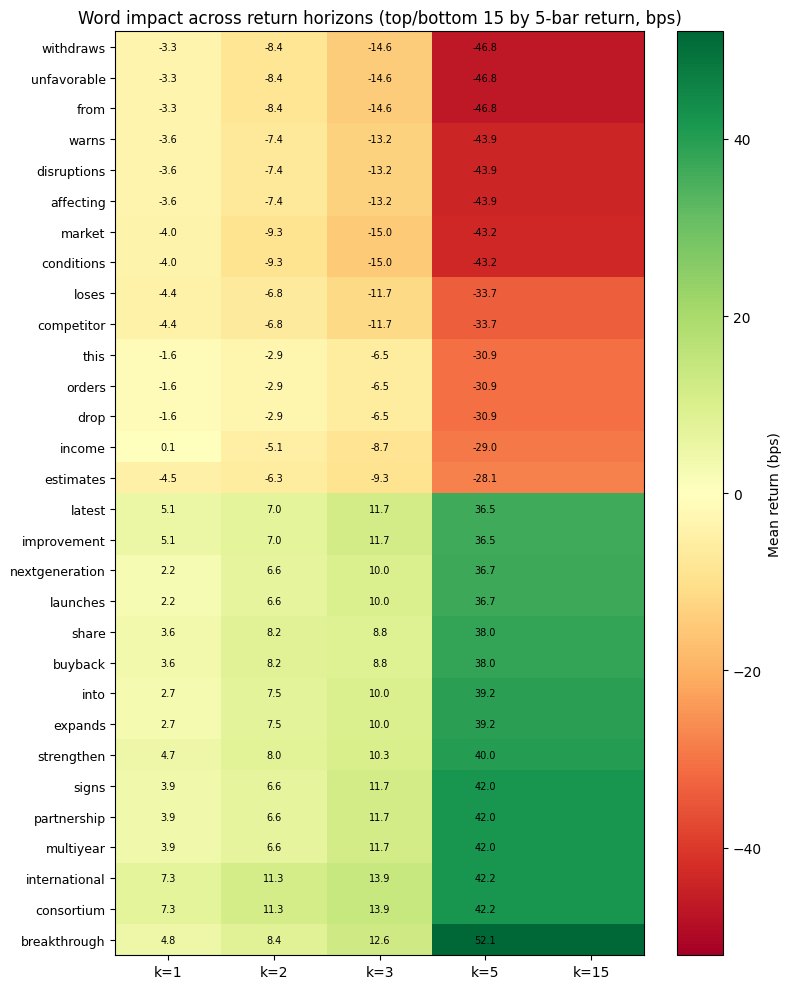

In [173]:
# Heatmap: mean return per word across k-step horizons
top_words_both = pd.concat([
    word_stats_df[word_stats_df['p_ret15'] < 0.05].nlargest(15, 'mean_ret15'),
    word_stats_df[word_stats_df['p_ret15'] < 0.05].nsmallest(15, 'mean_ret15')
]).drop_duplicates('word').set_index('word')

hmap_rows = []
for word in top_words_both.index:
    grp = word_rows[word_rows['word'] == word]
    hmap_rows.append({
        'word': word,
        'k=1': grp['ret_1'].mean() * 1e4,
        'k=2': grp['ret_2'].mean() * 1e4,
        'k=3': grp['ret_3'].mean() * 1e4,
        'k=5': grp['ret_15'].mean() * 1e4,
        'k=15': grp['ret_15'].mean() * 1e4,
    })
hmap_df = pd.DataFrame(hmap_rows).set_index('word').sort_values('k=15')

vmax = np.abs(hmap_df.values).max()
fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(hmap_df.values, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(5))
ax.set_xticklabels(['k=1', 'k=2', 'k=3', 'k=5', 'k=15'], fontsize=10)
ax.set_yticks(range(len(hmap_df)))
ax.set_yticklabels(hmap_df.index, fontsize=9)
plt.colorbar(im, ax=ax, label='Mean return (bps)')
ax.set_title('Word impact across return horizons (top/bottom 15 by 5-bar return, bps)')
for i in range(len(hmap_df)):
    for j in range(4):
        ax.text(j, i, f'{hmap_df.values[i,j]:.1f}', ha='center', va='center', fontsize=7)
plt.tight_layout()
plt.savefig('word_impact_heatmap.png', dpi=120)
plt.show()


In [174]:
print('='*60)
print('SESSION → COMPANY IDENTIFICATION SUMMARY')
print('='*60)
print(f'Training sessions analyzed : {len(final_predictions)}')
print(f'Unique companies found     : {len(all_companies)}')
print(f'Companies assigned         : {final_predictions["predicted_company"].nunique()}')
print()
print('Method agreement:')
tmp = all_preds.merge(final_predictions[['session','predicted_company']], on='session')
for col in ['predicted_owner_score','predicted_owner_count','predicted_owner_lift']:
    pct = (tmp[col] == tmp['predicted_company']).mean()
    print(f'  ensemble vs {col:<30}: {pct:.1%}')
print()
print('Confidence (top1 vs top2 margin):')
print(f'  Mean  : {final_predictions["score_margin"].mean():.3f}')
print(f'  Median: {final_predictions["score_margin"].median():.3f}')
print(f'  Min   : {final_predictions["score_margin"].min():.3f}')
print()
print('Low-confidence sessions (margin < 0.5):')
low_conf = final_predictions[final_predictions['score_margin'] < 0.5]
print(f'  {len(low_conf)} sessions ({len(low_conf)/len(final_predictions):.1%})')

print()
print('Final assignment table saved to: session_company_assignments.csv')
final_predictions.to_csv('session_company_assignments.csv', index=False)

SESSION → COMPANY IDENTIFICATION SUMMARY
Training sessions analyzed : 1000
Unique companies found     : 80
Companies assigned         : 80

Method agreement:
  ensemble vs predicted_owner_score         : 71.8%
  ensemble vs predicted_owner_count         : 36.7%
  ensemble vs predicted_owner_lift          : 77.2%

Confidence (top1 vs top2 margin):
  Mean  : 0.560
  Median: 0.512
  Min   : 0.000

Low-confidence sessions (margin < 0.5):
  487 sessions (48.7%)

Final assignment table saved to: session_company_assignments.csv
